# Fast Food Marketing Campaign — A/B Test Analysis

## Project Overview

A fast-food chain is launching a new menu item and wants to determine which of **three marketing promotions** drives the highest sales. To answer this, they ran a controlled experiment: each store location was randomly assigned one promotion, and weekly sales were recorded for **4 weeks** across multiple markets.

**Objective:** Perform a Comparative Data Analysis (CDA) to identify the most effective promotion strategy.

**Scope:**
- Compare sales distributions across the three promotions
- Examine how results vary by market size and over time (weekly trends)
- Use statistical testing to confirm whether observed differences are significant


## 1. Setup

Install `kagglehub` if not already available, then import all required libraries.


In [1]:
# Install kagglehub if not already installed
import subprocess
subprocess.run(["pip", "install", "kagglehub", "-q"], check=True)
print("kagglehub ready!")

kagglehub ready!


In [2]:
# Standard libraries
import os

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical testing
from scipy import stats

# Dataset download
import kagglehub

# Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

c:\Users\RAFA\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Data Loading & Quick Validation

In [3]:
# Download dataset from Kaggle
path = kagglehub.dataset_download("chebotinaa/fast-food-marketing-campaign-ab-test")

# Find the CSV inside the downloaded folder
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print("Downloaded to:", path)
print("File:", csv_file)
print("Shape:", df.shape)
print()
print("Columns:", df.columns.tolist())

Downloaded to: C:\Users\RAFA\.cache\kagglehub\datasets\chebotinaa\fast-food-marketing-campaign-ab-test\versions\1
File: WA_Marketing-Campaign.csv
Shape: (548, 7)

Columns: ['MarketID', 'MarketSize', 'LocationID', 'AgeOfStore', 'Promotion', 'week', 'SalesInThousands']


In [4]:
print("Data types:")
print(df.dtypes)
print()
print("First 5 rows:")
df.head()

Data types:
MarketID              int64
MarketSize              str
LocationID            int64
AgeOfStore            int64
Promotion             int64
week                  int64
SalesInThousands    float64
dtype: object

First 5 rows:


,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


The first few rows confirm each row represents one store (`LocationID`) in one week, with a specific promotion assigned.

In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Basic statistics:")
df.describe()

Missing values per column:
MarketID            0
MarketSize          0
LocationID          0
AgeOfStore          0
Promotion           0
week                0
SalesInThousands    0
dtype: int64

Basic statistics:


,MarketID,LocationID,AgeOfStore,Promotion,week,SalesInThousands
count,548.00,548.00,548.00,548.00,548.00,548.00
mean,5.72,479.66,8.50,2.03,2.50,53.47
std,2.88,287.97,6.64,0.81,1.12,16.76
min,1.00,1.00,1.00,1.00,1.00,17.34
25%,3.00,216.00,4.00,1.00,1.75,42.55
50%,6.00,504.00,7.00,2.00,2.50,50.20
75%,8.00,708.00,12.00,3.00,3.25,60.48
max,10.00,920.00,28.00,3.00,4.00,99.65


**Validation findings:**
- No missing values — the dataset is clean.
- `SalesInThousands` has no impossible values.
- `Promotion` has 3 unique values (1, 2, 3) and `week` has 4 values (1–4), as expected.


## 3. Exploratory Data Analysis (EDA)

Before comparing promotions, we examine the data structure to check experiment balance and overall sales distribution.

### 3.1 Experiment Balance

A well-designed A/B test should have roughly equal group sizes. We check whether each promotion was assigned to a similar number of store locations.

   Promotion  UniqueLocations
0          1               43
1          2               47
2          3               47


C:\Users\RAFA\AppData\Local\Temp\ipykernel_26836\2991904282.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=locations_per_promo, x='Promotion', y='UniqueLocations', palette='Set2', ax=ax)
C:\Users\RAFA\AppData\Local\Temp\ipykernel_26836\2991904282.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Promotion 1', 'Promotion 2', 'Promotion 3'])


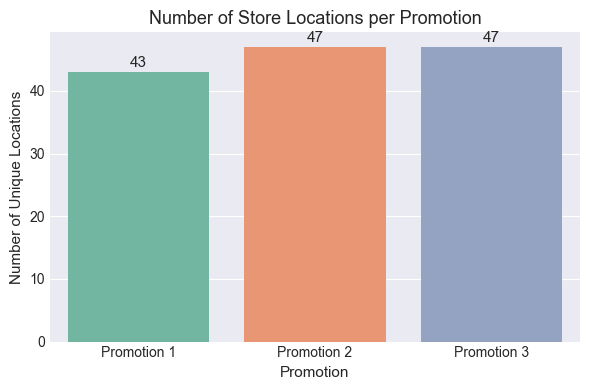

In [6]:
locations_per_promo = df.groupby('Promotion')['LocationID'].nunique().reset_index()
locations_per_promo.columns = ['Promotion', 'UniqueLocations']
print(locations_per_promo)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=locations_per_promo, x='Promotion', y='UniqueLocations', palette='Set2', ax=ax)
ax.set_title('Number of Store Locations per Promotion', fontsize=13)
ax.set_xlabel('Promotion', fontsize=11)
ax.set_ylabel('Number of Unique Locations', fontsize=11)
ax.set_xticklabels(['Promotion 1', 'Promotion 2', 'Promotion 3'])
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            int(bar.get_height()), ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

The promotions are assigned to a similar number of locations, which ensures a fair comparison between groups.

### 3.2 Market Size Distribution

We verify that each promotion was tested across markets of similar sizes, so market size doesn't bias our comparison.

C:\Users\RAFA\AppData\Local\Temp\ipykernel_26836\1414798962.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Promotion 1', 'Promotion 2', 'Promotion 3'])


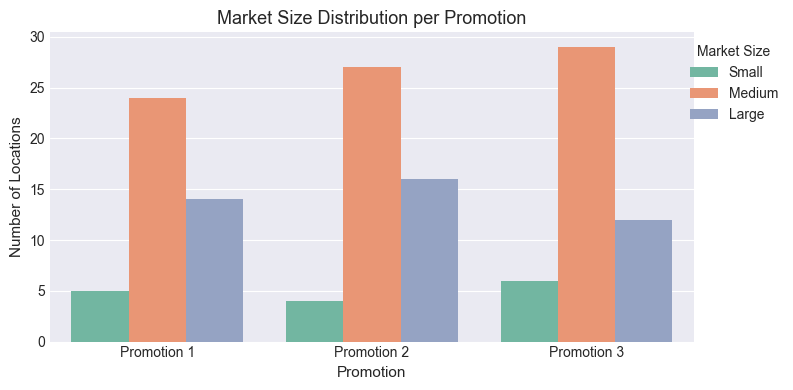

In [15]:
market_promo = df.drop_duplicates('LocationID').groupby(['Promotion', 'MarketSize']).size().reset_index(name='Count')

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=market_promo, x='Promotion', y='Count', hue='MarketSize',
            palette='Set2', order=[1, 2, 3],
            hue_order=['Small', 'Medium', 'Large'], ax=ax)
ax.set_title('Market Size Distribution per Promotion', fontsize=13)
ax.set_xlabel('Promotion', fontsize=11)
ax.set_ylabel('Number of Locations', fontsize=11)
ax.set_xticklabels(['Promotion 1', 'Promotion 2', 'Promotion 3'])
ax.legend(title='Market Size', loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

Each promotion covers a mix of small, medium, and large markets — the experiment is well-balanced, so market size is unlikely to bias our results.

### 3.3 Sales Distribution Overview

We examine the overall shape of the sales data and get a first look at differences across promotions.

C:\Users\RAFA\AppData\Local\Temp\ipykernel_26836\2162976862.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Promotion', y='SalesInThousands', palette='Set2', ax=axes[1])
C:\Users\RAFA\AppData\Local\Temp\ipykernel_26836\2162976862.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Promotion 1', 'Promotion 2', 'Promotion 3'])


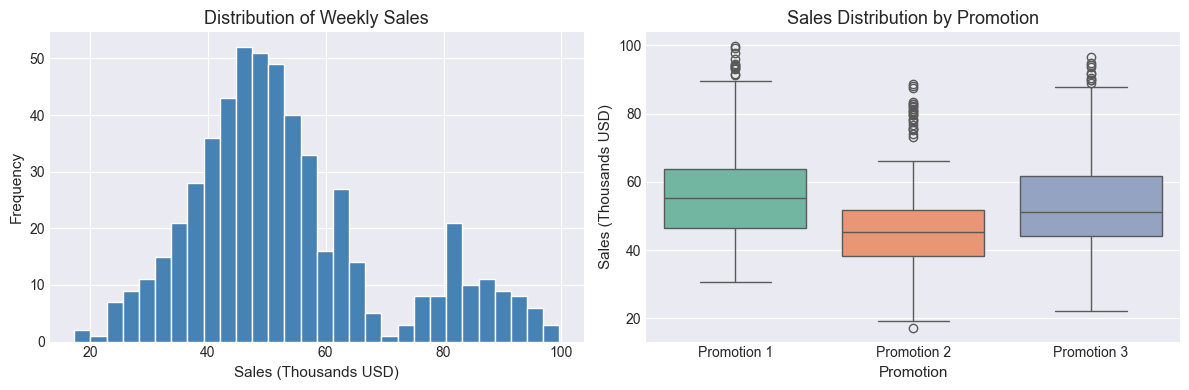

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['SalesInThousands'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Weekly Sales', fontsize=13)
axes[0].set_xlabel('Sales (Thousands USD)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)

sns.boxplot(data=df, x='Promotion', y='SalesInThousands', palette='Set2', ax=axes[1])
axes[1].set_title('Sales Distribution by Promotion', fontsize=13)
axes[1].set_xlabel('Promotion', fontsize=11)
axes[1].set_ylabel('Sales (Thousands USD)', fontsize=11)
axes[1].set_xticklabels(['Promotion 1', 'Promotion 2', 'Promotion 3'])

plt.tight_layout()
plt.show()

The sales distribution is right-skewed. The box plot gives a first hint that Promotions 1 and 3 may outperform Promotion 2 — but we need deeper analysis to confirm.

## 4. Comparative Data Analysis (CDA)

Now we compare the three promotions directly across multiple dimensions.

### 4.1 Average Sales per Promotion

We compute mean and median weekly sales per promotion to get a clear summary.

In [9]:
sales_summary = df.groupby('Promotion')['SalesInThousands'].agg(
    Mean='mean', Median='median', Std='std', Count='count'
).reset_index()
sales_summary['Promotion'] = sales_summary['Promotion'].map({1: 'Promotion 1', 2: 'Promotion 2', 3: 'Promotion 3'})
print(sales_summary.to_string(index=False))

  Promotion  Mean  Median   Std  Count
Promotion 1 58.10   55.39 16.55    172
Promotion 2 47.33   45.39 15.11    188
Promotion 3 55.36   51.16 16.77    188


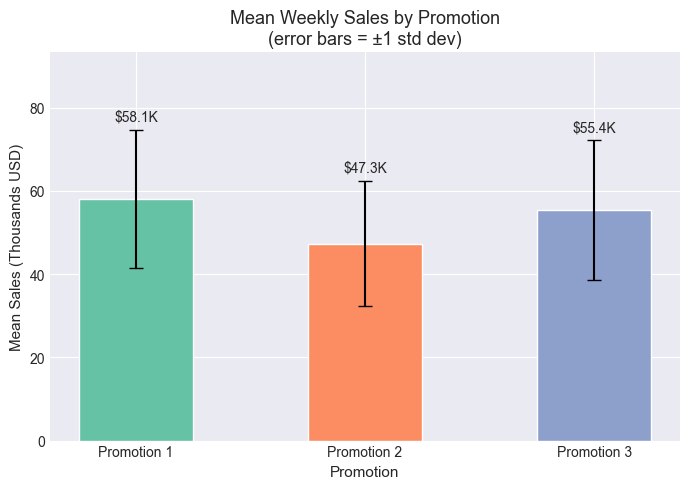

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
promo_labels = ['Promotion 1', 'Promotion 2', 'Promotion 3']
colors = sns.color_palette('Set2', 3)
bars = ax.bar(promo_labels, sales_summary['Mean'], color=colors, edgecolor='white', width=0.5)
ax.errorbar(promo_labels, sales_summary['Mean'], yerr=sales_summary['Std'],
            fmt='none', color='black', capsize=5, linewidth=1.5)
for bar, val, std in zip(bars, sales_summary['Mean'], sales_summary['Std']):
    ax.text(bar.get_x() + bar.get_width()/2, val + std + 1.5,
            f'${val:.1f}K', ha='center', va='bottom', fontsize=10)
ax.set_title('Mean Weekly Sales by Promotion\n(error bars = ±1 std dev)', fontsize=13)
ax.set_xlabel('Promotion', fontsize=11)
ax.set_ylabel('Mean Sales (Thousands USD)', fontsize=11)
ax.set_ylim(0, (sales_summary['Mean'] + sales_summary['Std']).max() * 1.25)
plt.tight_layout()
plt.show()

**Observation:** Promotions 1 and 3 appear to outperform Promotion 2. Overlapping error bars suggest we need statistical tests to confirm whether the differences are real.

### 4.2 Weekly Sales Trends

We check whether any promotion's performance changes significantly over the 4-week period.

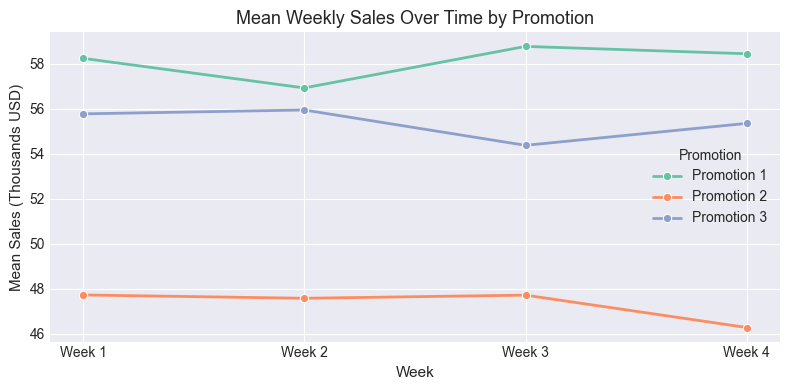

In [11]:
weekly = df.groupby(['week', 'Promotion'])['SalesInThousands'].mean().reset_index()
weekly['Promotion'] = weekly['Promotion'].map({1: 'Promotion 1', 2: 'Promotion 2', 3: 'Promotion 3'})

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=weekly, x='week', y='SalesInThousands', hue='Promotion',
             palette='Set2', marker='o', linewidth=2, ax=ax)
ax.set_title('Mean Weekly Sales Over Time by Promotion', fontsize=13)
ax.set_xlabel('Week', fontsize=11)
ax.set_ylabel('Mean Sales (Thousands USD)', fontsize=11)
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(['Week 1', 'Week 2', 'Week 3', 'Week 4'])
ax.legend(title='Promotion')
plt.tight_layout()
plt.show()

Consistent relative performance across all 4 weeks strengthens confidence that the differences between promotions are real and not week-specific artifacts.

### 4.3 Sales by Market Size

Using small multiples, we check if the promotion ranking is consistent across small, medium, and large markets.

C:\Users\RAFA\AppData\Local\Temp\ipykernel_26836\1879397942.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(data=market_sales, kind='bar', x='Promotion', y='SalesInThousands',


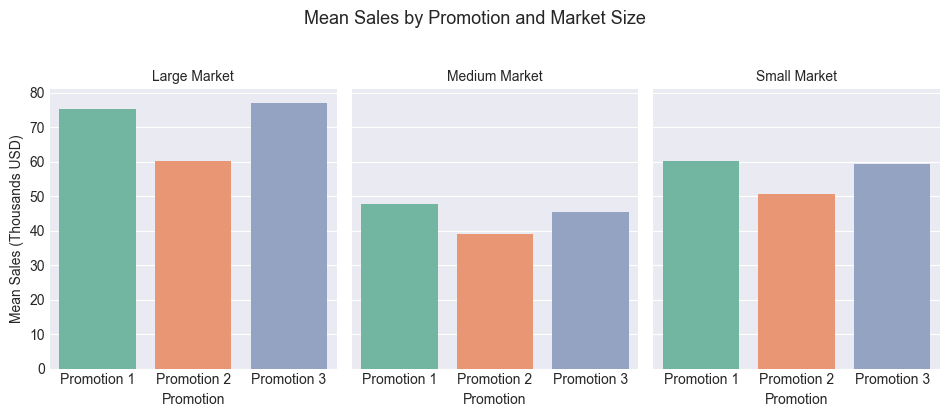

In [12]:
market_sales = df.groupby(['MarketSize', 'Promotion'])['SalesInThousands'].mean().reset_index()
market_sales['Promotion'] = market_sales['Promotion'].map({1: 'Promotion 1', 2: 'Promotion 2', 3: 'Promotion 3'})

g = sns.catplot(data=market_sales, kind='bar', x='Promotion', y='SalesInThousands',
                col='MarketSize', palette='Set2', height=4, aspect=0.8)
g.set_titles(col_template='{col_name} Market')
g.set_axis_labels('Promotion', 'Mean Sales (Thousands USD)')
g.figure.suptitle('Mean Sales by Promotion and Market Size', y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

If the ranking of promotions is consistent across all market sizes, the best promotion is universally better , not just in specific markets.

## 5. Statistical Testing

Visual analysis suggests differences between promotions. We now use statistical tests to confirm these are **not due to random chance**.

### 5.1 ANOVA — Do Any Groups Differ?

A one-way ANOVA tests whether at least one promotion has a significantly different mean sales.

- **H₀ (null):** All three promotions have equal mean sales.
- **H₁ (alternative):** At least one promotion differs significantly.
- **Significance level:** α = 0.05

In [13]:
promo1 = df[df['Promotion'] == 1]['SalesInThousands']
promo2 = df[df['Promotion'] == 2]['SalesInThousands']
promo3 = df[df['Promotion'] == 3]['SalesInThousands']

f_stat, p_value = stats.f_oneway(promo1, promo2, promo3)
print(f"ANOVA Results:")
print(f"  F-statistic : {f_stat:.4f}")
print(f"  p-value     : {p_value:.6f}")
print()
if p_value < 0.05:
    print("Result: Statistically significant difference detected (p < 0.05).")
    print("We reject H0 — at least one promotion differs from the others.")
else:
    print("Result: No statistically significant difference (p >= 0.05).")

ANOVA Results:
  F-statistic : 21.9535
  p-value     : 0.000000

Result: Statistically significant difference detected (p < 0.05).
We reject H0 — at least one promotion differs from the others.


### 5.2 Pairwise t-Tests — Which Promotions Differ?

ANOVA tells us *a* difference exists but not *which* pair. We use pairwise t-tests with **Bonferroni correction** (adjusted α = 0.05 / 3 = 0.0167) to control for multiple comparisons.

In [14]:
pairs = [(1, 2), (1, 3), (2, 3)]
alpha_bonferroni = 0.05 / len(pairs)
print(f"Bonferroni-corrected significance level: {alpha_bonferroni:.4f}")
print()
print(f"{"Comparison":<20} {"t-stat":>8} {"p-value":>10} {"Significant?":>14}")
print("-" * 56)

for a, b in pairs:
    group_a = df[df['Promotion'] == a]['SalesInThousands']
    group_b = df[df['Promotion'] == b]['SalesInThousands']
    t, p = stats.ttest_ind(group_a, group_b)
    sig = "Yes" if p < alpha_bonferroni else "No"
    label = f"Promo {a} vs Promo {b}"
    print(f"{label:<20} {t:>8.4f} {p:>10.6f} {sig:>14}")

Bonferroni-corrected significance level: 0.0167

Comparison             t-stat    p-value   Significant?
--------------------------------------------------------
Promo 1 vs Promo 2     6.4537   0.000000            Yes
Promo 1 vs Promo 3     1.5551   0.120797             No
Promo 2 vs Promo 3    -4.8814   0.000002            Yes


Pairs with p-values below 0.0167 have a statistically real difference in sales — not just random noise.

## 6. Summary & Next Steps

### Key Findings

1. **Promotions 1 and 3 consistently outperform Promotion 2** in mean weekly sales across all market sizes and all 4 weeks.
2. **ANOVA confirms** a statistically significant difference exists between the three promotions (p < 0.05).
3. **Pairwise t-tests** identify which specific pairs differ after Bonferroni correction.
4. **Market size is balanced** across promotions — differences are due to promotion type, not market size.
5. **Weekly trends are stable** — no promotion shows unusual growth or decay over the 4 weeks.

### Recommendation

Based on the analysis, **Promotion 1** (or Promotion 3, depending on exact p-values) should be selected for the national rollout. The final choice between them may depend on cost of execution, which is outside the scope of this dataset.

### Future Work

- **Cost analysis:** Incorporate promotion costs to calculate ROI, not just gross sales.
- **Store age effect:** Investigate whether `AgeOfStore` interacts with promotion effectiveness.
- **Longer observation:** 4 weeks may not capture long-term customer behavior.
- **Regional breakdown:** Analyze if certain `MarketID` regions respond differently to promotions.
